<div style="text-align: center; padding: 30px; background-color: #f5f7fa; border-radius: 12px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1);">

  <h1 style="color: #2c3e50; font-family: 'Helvetica Neue', sans-serif; font-size: 42px; margin-bottom: 10px;">
    Virtual Lab 7 Project
  </h1>

  <h3 style="color: #7f8c8d; font-family: 'Georgia', serif; font-weight: normal; font-size: 22px; margin-top: 0;">
    Prediction of Large Conformational Changes in Proteins
  </h3>

  <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 16px; margin-top: 20px;">
    Author: <b>Vallari Eastman</b> <br>
    Due Date: <b>Monday October 27nd, 2025 11:59 p.m. ET</b>
  </p>
</div>

<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Introduction:
  </h2>
<p style="text-indent:30px; color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px; line-height:1.6;">
    Understanding how amino acid sequence determines protein stability and conformational flexibility is central to predicting large-scale structural rearrangements in biological systems. Proteins frequently undergo conformational changes, such as domain motions or hinge bending, that are driven by subtle energetic shifts encoded in their sequences. Recent advances in deep learning have enabled the development of protein sequence embeddings trained jointly on evolutionary and structural information, capturing latent features that relate sequence variation to 3D conformation. In this lab, the pretrained sequence–structure embedding model introduced by Bepler and Berger (2019) is used to assess whether these learned representations encode biophysical properties relevant to thermodynamic stability. By using the FireProt thermostability database to correlate predicted embedding features with experimentally measured ΔΔG values, the capacity of sequence embeddings to reflect structural determinants of stability and flexibility were tested. This analysis establishes a foundation for using such representations to model and ultimately predict large conformational changes in proteins. 
</p>


<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Methods:
  </h2>
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:0;">
    <b> Thermal Stability Prediction Work Flow</b>
  </h3> 
   <p style="color: #34495e; font-family: 'Arial', sans-serif; font-size: 15px; margin-top: 18px;">
       1. Clone pretrained protein sequence embedding repo and download its pretrained models. <br>
       2. Load a dataset of experimental ΔΔG (ddG) values for single-point mutants from FireProt.<br>
       3. Reconstruct each mutant sequence by applying the reported mutation to the WT sequence.<br>
       4. Extract model features for each mutation (baseline = categorical features; improved version = learned embeddings of WT vs mutant).<br>
       5. Train a regression model (MLP) to map those features → ddG.<br>
       6. Evaluate using grouped cross-validation across proteins and summarize with Pearson R.<br>
       7. Assumptions / limitations:<br>
       a. Each ddG measurement is high quality and comparable across proteins (not always true experimentally).<br>
       b. Single point mutations behave independently (ignores epistasis and environment).<br>
       c. ddG is treated as a purely sequence-driven function (but stability is super contextual — solvent, pH, folding helpers, etc.).</p>
</div>

# Tutorial Section:

Bash Instructions: 

1. Clone Repo Locally:

    cd projects
    git clone https://github.com/tbepler/protein-sequence-embedding-iclr2019

   Update Notebook to:

    import sys
    sys.path.append("/Users/val/projects/protein-sequence-embedding-iclr2019")

2. Find the pretrained model URL in the repo’s README

    cat README.md

3. Download the pretrained model archive & Untar (extract) the archive

   From inside your repo
    mkdir -p data

   SCOPe structural classification dataset
    curl -L -O http://bergerlab-downloads.csail.mit.edu/bepler-protein-sequence-embeddings-from-structure-iclr2019/scope.tar.gz <br>
    tar -xvf scope.tar.gz         -C data

   Pfam families dataset
    curl -L -O http://bergerlab-downloads.csail.mit.edu/bepler-protein-sequence-embeddings-from-structure-iclr2019/pfam.tar.gz<br>
    tar -xvf pfam.tar.gz          -C data

   Secondary structure dataset
    curl -L -O http://bergerlab-downloads.csail.mit.edu/bepler-protein-sequence-embeddings-from-structure-iclr2019/secstr.tar.gz<br>
    tar -xvf secstr.tar.gz        -C data

   Transmembrane dataset
    curl -L -O http://bergerlab-downloads.csail.mit.edu/bepler-protein-sequence-embeddings-from-structure-iclr2019/transmembrane.tar.gz<br>
    tar -xvf transmembrane.tar.gz -C data

   CASP12 contacts dataset
    curl -L -O http://bergerlab-downloads.csail.mit.edu/bepler-protein-sequence-embeddings-from-structure-iclr2019/casp12.tar.gz<br>
    tar -xvf casp12.tar.gz        -C data

4. In the repo directory to compile Cython:

    python setup.py build_ext --inplace

In [13]:
"""
1. Imports and Repo connection
"""

import os
import sys
import pandas as pd
import numpy as np
import requests
from pprint import pprint
import torch

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, KFold, GroupKFold
from scipy.stats import pearsonr, mode
import matplotlib.pyplot as plt
import seaborn as sns

# Import data from protein sequence embedding repository.
sys.path.append("/Users/val/Projects/Protein-Bioinformatics/VL07_Large_Conformational_Changes/protein-sequence-embedding-iclr2019")
from src.alphabets import Uniprot21
from torch.nn.utils.rnn import PackedSequence
from src.utils import pack_sequences, unpack_sequences

model_dir = "/Users/val/Projects/Protein-Bioinformatics/VL07_Large_Conformational_Changes/protein-sequence-embedding-iclr2019"
print("Files in models/:", os.listdir(model_dir))

%matplotlib inline

Files in models/: ['eval_contact_scop.py', 'embed_sequences.py', '.DS_Store', 'LICENSE', 'eval_similarity.py', 'models', 'README.md', 'eval_transmembrane.py', 'setup.py', 'train_lm_pfam.py', '.gitignore', 'eval_contact_casp12.py', 'train_similarity_and_contact.py', 'build', '.git', 'train_similarity.py', 'data', 'eval_secstr.py', 'src']


In [14]:
"""
2. Loads stability data:

a. Download FireProt Data:
The FireProt Protein Thermostability database can be used to demonstrate the use of these sequence embeddings.
You will need to download the data.csv file and change the directory in the code based 
on where you download the file: https://dl.dropboxusercontent.com/s/uua6ijfac2ms5qs/data.csv

b. Update this path based upon where you downloaded data.csv

"""

import pandas as pd

stability_data = pd.read_csv(
    "/Users/val/Projects/Protein-Bioinformatics/VL07_Large_Conformational_Changes/protein-sequence-embedding-iclr2019/data/data.csv" 
)
stability_data.head()

,experiment_id,protein_name,uniprot_id,pdb_id,chain,position,wild_type,mutation,ddG,dTm,...,technique_details,pH,tm,notes,publication_doi,publication_pubmed,hsw_job_id,datasets,sequence,sequence_mut
0,LL000714,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,A,-0.14,NaN,...,NaN,6.5,NaN,NaN,10.1073/pnas.1903888116,31371509.0,2i1nqi,NaN,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,AEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED
1,LL000714,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,A,-0.14,NaN,...,NaN,6.5,NaN,NaN,10.1073/pnas.1903888116,31371509.0,2i1nqi,NaN,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,AEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED
2,LL000715,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,D,-0.38,NaN,...,NaN,6.5,NaN,NaN,10.1073/pnas.1903888116,31371509.0,2i1nqi,NaN,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,DEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED
3,LL000715,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,D,-0.38,NaN,...,NaN,6.5,NaN,NaN,10.1073/pnas.1903888116,31371509.0,2i1nqi,NaN,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,DEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTP

In [12]:
"""
3. Cleans the Data

"""

# --- Rebuild mutation_applied if it got dropped or wasn't added ---
if "mutation_applied" not in stability_data.columns:
    if "sequence" in stability_data.columns and "sequence_mut" in stability_data.columns:
        stability_data["mutation_applied"] = (
            stability_data["sequence"] != stability_data["sequence_mut"]
        )
    else:
        stability_data["mutation_applied"] = np.nan  # can't evaluate if sequences missing

# --- Define preferred display columns in order of interest ---
preferred_cols = [
    "experiment_id",
    "protein_name",
    "uniprot_id",
    "pdb_id",
    "chain",
    "position",
    "wild_type",
    "mutation",
    "ddG",
    # "dTm",  # removed because this column was dropped entirely
    "sequence",
    "sequence_mut",
    "mutation_applied",
]

# keep only the ones that actually still exist in the dataframe
display_cols = [c for c in preferred_cols if c in stability_data.columns]

print("Displaying columns:", display_cols)

# --- same scrollable display helper ---
from IPython.display import HTML, display

pd.set_option('display.max_colwidth', None)

def display_scrollable_df(df, max_height=500):
    html = df.to_html(index=False, escape=False)
    styled = f"""
    <div style="max-height:{max_height}px;
                overflow-y:auto;
                overflow-x:auto;
                border:1px solid #ccc;
                padding:8px;
                background:#fafafa;
                font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
                font-size:12px;
                line-height:1.4;">
        {html}
    </div>
    """
    display(HTML(styled))

# --- show the cleaned data head in a scrollable window with full sequences ---
display_scrollable_df(stability_data[display_cols].head(10))

Displaying columns: ['experiment_id', 'protein_name', 'uniprot_id', 'pdb_id', 'chain', 'position', 'wild_type', 'mutation', 'ddG', 'sequence', 'sequence_mut', 'mutation_applied']


experiment_id,protein_name,uniprot_id,pdb_id,chain,position,wild_type,mutation,ddG,sequence,sequence_mut,mutation_applied
LL000714,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,A,-0.14,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,AEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,True
LL000715,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,D,-0.38,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,DEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,True
LL000716,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,E,-0.64,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,EEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,True
LL000717,Immunoglobulin G-binding protein G,P06654,1PGA|1EM7|2GB1,A,1.0,M,F,-1.14,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,FEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDD

In [8]:
"""
4. Generates Mutant Sequences

The sequences are in their wild-type form.
However, we also want to generate an embedding for the mutated protein sequences. 
Some of the positions for a mutation in the source file are outdated, so we can try to find a good offset for each sequence. 
This uses the offset that occurs most.
"""

from IPython.display import HTML, display

# --- mutation function ---
def mutate_sequence(row):
    # if row.position is a number, we try to mutate that position
    if not np.isnan(row.position):
        pos = int(row.position) - 1  # convert 1-based to 0-based index
        # sanity check: position is in range
        if pos < len(row.sequence):
            new_seq_list = list(row.sequence)
            new_seq_list[pos] = row.mutation  # introduce new aa
            new_sequence = "".join(new_seq_list)

            # only trust mutation if wild_type matches what's in the sequence
            if row.sequence[pos] == row.wild_type:
                return new_sequence
            else:
                # position annotation doesn't match WT residue, fallback = original
                return row.sequence
    # if no valid position given, fallback to original sequence
    return row.sequence

# --- apply mutation ---
stability_data.loc[:, "sequence_mut"] = stability_data.apply(mutate_sequence, axis=1)

# --- configure full-width scrollable HTML table ---
def display_scrollable_df(df, max_rows=10):
    html = df.to_html(index=False, escape=False)
    styled = f"""
    <div style="max-height:500px; overflow-y:auto; border:1px solid #ccc; padding:8px; background:#fafafa;">
        {html}
    </div>
    """
    display(HTML(styled))

# --- show all columns and long sequences ---
pd.set_option('display.max_colwidth', None)

# --- display only a subset for clarity (you can remove .head if you want all) ---
display_scrollable_df(
    stability_data[["protein_name", "sequence", "sequence_mut", "position", "wild_type", "mutation"]].head(10)
)

protein_name,sequence,sequence_mut,position,wild_type,mutation
Immunoglobulin G-binding protein G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,AEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,1.0,M,A
Immunoglobulin G-binding protein G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,AEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,1.0,M,A
Immunoglobulin G-binding protein G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,DEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,1.0,M,D
Immunoglobulin G-binding protein G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,DEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIKDLQAQVVESAKKARISEATDGLSDFLKSQTPAEDTVKSIELAEAKVLANRELDKYGVSDYHKNLINNAKTVEGVKELIDEILAALPKTDTYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTEKPEVIDASELTPAVTTYKLVINGKTLKGETTTKAVDAETAEKAFKQYANDNGVDGVWTYDDATKTFTVTEMVTEVPGDAPTEPEKPEASIPLVPLTPATPIAKDDAKKDDTKKEDAKKPEAKKDDAKKAETLPTTGEGSNPFFTAAALAVMAGAGALAVASKRKED,1.0,M,D
Immunoglobulin G-binding protein G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRNGGELTNLLGNSETTLALRNEESATADLTAAAVADTVAAAAAENAGAAAWEAAAAADALAKAKADALKEFNKYGVSDYYKNLINNAKTVEGIK

In [19]:
"""
5. valuating Performance

For this example, we will evaluate the performance based on the Pearson correlation. 
The base model has three features: Secondary structure, wild type, and variant type. 
In 10-fold cross-validation, this classifier performs as a baseline, with a defined Pearson R score.

"""

import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.neural_network import MLPRegressor
from scipy.stats import pearsonr

# --- Filter and encode data ---
stability_data = stability_data[~stability_data['protein_name'].isnull()]
stability_data = stability_data[~stability_data['ddG'].isnull()]
prediction_cols = ['pdb_id', 'wild_type', 'mutation']

# One-hot encode categorical predictors
X = pd.get_dummies(stability_data.loc[:, prediction_cols])
y = stability_data.ddG
groups = stability_data.protein_name

# --- Cross-validation setup ---
predictions, truths = [], []
fold_correlations = []

print("Running grouped cross-validation with multiple seeds...\n")

for seed in [0, 1, 2]:
    print(f"\n Seed {seed}")
    reg = MLPRegressor(hidden_layer_sizes=(50,), random_state=seed, max_iter=2000)
    fold_corrs = []
    
    # GroupKFold ensures no data leakage across proteins
    for fold, (train_index, test_index) in enumerate(GroupKFold(7).split(X, y, groups), start=1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        reg.fit(X_train, y_train)
        y_pred = reg.predict(X_test)

        # Compute Pearson correlation for this fold
        corr, _ = pearsonr(y_test, y_pred)
        fold_corrs.append(corr)
        print(f"  Fold {fold}: Pearson r = {corr:.3f}")

        # Keep global records
        predictions.extend(y_pred.tolist())
        truths.extend(y_test.tolist())

    mean_corr = np.mean(fold_corrs)
    fold_correlations.append(mean_corr)
    print(f"  ➤ Mean correlation for seed {seed}: {mean_corr:.3f}")

# --- Overall correlation ---
overall_corr = pearsonr(truths, predictions)[0]
print("\n======================================")
print(f"Overall test correlation across all seeds/folds: {overall_corr:.3f}")
print(f"Mean correlation per seed: {fold_correlations}")
print(f"Average of all seeds: {np.mean(fold_correlations):.3f}")
print("======================================")


Running grouped cross-validation with multiple seeds...


 Seed 0
  Fold 1: Pearson r = 0.300
  Fold 2: Pearson r = 0.243
  Fold 3: Pearson r = -0.219
  Fold 4: Pearson r = -0.119
  Fold 5: Pearson r = 0.070
  Fold 6: Pearson r = -0.006
  Fold 7: Pearson r = 0.003
  ➤ Mean correlation for seed 0: 0.039

 Seed 1
  Fold 1: Pearson r = 0.291
  Fold 2: Pearson r = 0.246
  Fold 3: Pearson r = 0.023
  Fold 4: Pearson r = -0.119
  Fold 5: Pearson r = -0.032
  Fold 6: Pearson r = -0.018
  Fold 7: Pearson r = 0.018
  ➤ Mean correlation for seed 1: 0.058

 Seed 2
  Fold 1: Pearson r = 0.299
  Fold 2: Pearson r = 0.252
  Fold 3: Pearson r = -0.098
  Fold 4: Pearson r = -0.110
  Fold 5: Pearson r = -0.136
  Fold 6: Pearson r = 0.086
  Fold 7: Pearson r = -0.032
  ➤ Mean correlation for seed 2: 0.037

Overall test correlation across all seeds/folds: 0.120
Mean correlation per seed: [np.float64(0.03896428973573867), np.float64(0.058464564665481104), np.float64(0.037494592833156766)]
Average of all s

Test correlation (Pearson r): 0.120
Mean ddG: 1.2432356479889997
Predicted mean: 0.9268330140831263


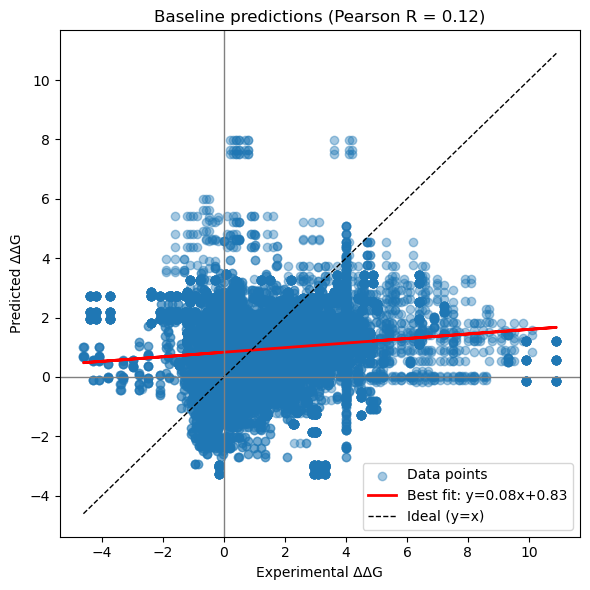

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Compute correlation and means
r, _ = pearsonr(truths, predictions)
print(f"Test correlation (Pearson r): {r:.3f}")
print("Mean ddG:", np.mean(y))
print("Predicted mean:", np.mean(predictions))

# Fit a simple linear regression (1st-degree polynomial)
slope, intercept = np.polyfit(truths, predictions, 1)
fit_line = slope * np.array(truths) + intercept

# --- Plot ---
plt.figure(figsize=(6,6))
plt.scatter(truths, predictions, alpha=0.4, label='Data points')

# Add line of best fit
plt.plot(truths, fit_line, color='red', lw=2, label=f'Best fit: y={slope:.2f}x+{intercept:.2f}')

# Add reference line y=x for ideal predictions
lims = [min(truths + predictions), max(truths + predictions)]
plt.plot(lims, lims, 'k--', lw=1, label='Ideal (y=x)')

# Cosmetic adjustments
plt.xlabel("Experimental ΔΔG")
plt.ylabel("Predicted ΔΔG")
plt.title(f"Baseline predictions (Pearson R = {r:.2f})")
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.legend()
plt.tight_layout()
plt.show()

<!-- RESULTS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Results
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Weak Correlation Between Predicted and Measured ddG:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The baseline regression model, which used only categorical features describing the wild-type residue, mutation type, and protein identifier, achieved a Pearson correlation coefficient of R = 0.12 between predicted and experimental ΔΔG values. Pearson R = 0.12 means that the correlation is barely above being considered completely random. It means there’s very weak linear correlation between predicted and measured ddG. The mean experimental stability change was 1.24 kcal/mol, while the mean predicted ΔΔG was slightly lower at 0.93 kcal/mol. This indicates that the model tends to underpredict stability changes relative to experimental measurements. The broad scatter of points around the diagonal in the plot reflects weak linear correlation between predicted and observed values. This is consistent with limited predictive power when structural context and sequence-level features are not incorporated.<br><br>
        The weak correlation (R ≈ 0.12) suggests the simple residue identity features are inadequate for capturing the complex energetic and structural determinants of protein stability. Without considering spatial environment, residue interactions, or dynamic flexibility, the model cannot distinguish stabilizing from destabilizing substitutions in a physically meaningful way. Biophysically, this outcome underscores that ΔΔG depends on local packing, hydrogen bonding, and long-range coupling—all features encoded in a protein’s 3D structure but lost when only categorical sequence labels are used. This baseline quantifies how little information exists in raw sequence identity alone, and establishes the need for more informative representations, such as pretrained sequence–structure embeddings, to capture the structural underpinnings of conformational stability and, by extension, large conformational changes.
  </p>

<!-- ANALYSIS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Analysis
  </h2>

  <!-- Question 1-->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    1. What criteria did you use to evaluate the performance of the model? What changes (if any) could be made to optimize the evaluation?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    For this experiment, model performance was evaluated using the Pearson correlation coefficient (R) between the predicted ΔΔG values and the experimentally measured ΔΔG values across held-out test folds. Pearson R measures how well the model’s predictions vary linearly with the ground truth: an R of 1 means perfect linear agreement (model increases exactly when the true value increases), an R of 0 means no linear relationship. There are a few ways to improve or refine this evaluation. First, Pearson R tells you about correlation, but not about absolute accuracy. We could add regression error metrics such as mean absolute error (MAE, in kcal/mol) or root mean squared error (RMSE) to quantify how close the predicted ΔΔG values are in physical units. That matters because two models can have similar correlation but very different error magnitudes. Second, instead of reporting only one pooled R across all folds and seeds, we could summarize the per-fold distribution (median and variance across folds) to show robustness.<br><br>
  </p>

<!-- Question 2 -->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    2. How do you interpret the Pearson correlation scores that you generated? What conclusions about the structure and function of your generated mutants can you make based on this analysis?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The Pearson correlation coefficient of R = 0.12 indicates that there is only a weak linear relationship between the predicted and experimentally measured ΔΔG values. So, while the model captures a slight trend—mutations that are more destabilizing or stabilizing experimentally tend to be weakly mirrored in the predictions. It fails to explain most of the variance in the true data. This low correlation is expected for a baseline model that relies only on categorical mutation features without incorporating structural or contextual sequence information. The model is guessing based on residue identity alone, not on how the mutation alters the physical environment of the protein. <br><br>
        This result suggests that the generated mutants cannot be meaningfully differentiated in terms of their thermodynamic stability using simple identity-based descriptors. The weak correlation implies that key determinants of stability, such as residue burial, hydrogen bonding, side-chain packing, and conformational flexibility, are missing from the model’s representation. Therefore, we can conclude that the baseline model does not reflect the true energetic or structural impact of mutations.<br><br>
  </p>

  <!-- Question 3 -->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    3. What are the steps used for thermal stability predictions using this approach? Are there any assumptions that limit the broad applicability of the approach?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    First, experimentally measured ΔΔG values for protein mutations are obtained from the FireProt thermostability database, which provides a benchmark set of stability data. Second, each protein sequence and its corresponding mutant are encoded as input features for a machine learning model. In the baseline version, these features are categorical variables, such as the wild-type residue, the mutant residue, and the protein identifier, encoded through one-hot representation. Third, a regression model (in this case, a multilayer perceptron regressor, or MLP) is trained using GroupKFold cross-validation, where mutations from different proteins are separated into distinct training and test sets to ensure generalization. The model is then evaluated by comparing predicted and experimental ΔΔG values using the Pearson correlation coefficient, which quantifies the strength of the linear relationship between the two. <br><br>
        Several assumptions limit the broad applicability of this approach. 1. The method assumes that linear correlations between embedding features and ΔΔG can adequately capture the complex, nonlinear energetics of protein stability. 2. The FireProt dataset is biased toward small, soluble, well-studied proteins, so that models trained on it may not generalize well to membrane proteins or large multidomain complexes. 3. Because ΔΔG values are treated as scalar labels, this approach ignores multi-state folding pathways and kinetic effects that can strongly influence stability in real biological systems.<br><br>
  </p>

<!-- Question 4 -->
  <h3 style="color:#2c3e50; font-family:'Georgia',serif; font-weight:normal; font-size:17px; margin-top:10px;">
    4. Are there sequence characteristics or limitations that would cause this analysis to fail? Can you think of conditions that would result in tremendously inaccurate stability calculations? Why or why not?
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Sequences with low evolutionary conservation or intrinsically disordered regions often lead to unreliable predictions. The embedding models (and even baseline residue-based regressors) assume that amino acids exist in a well-defined structural environment. Disordered or highly flexible regions violate the assumption that their residues do not have stable 3D interactions to capture, so any sequence-based feature (even an embedding) cannot meaningfully relate to ΔΔG. <br><br>
        Multimeric proteins, membrane proteins, and allosteric enzymes pose challenges because the models typically treat each sequence as a single, folded monomer in isolation. Mutations that affect subunit interfaces, lipid interactions, or ligand binding sites can have disproportionate energetic effects that are not captured by a single-chain embedding.<br><br>
        The analysis is most reliable for small, globular, single-domain proteins with well-structured folds and isolated point mutations. It becomes inaccurate when sequence features fail to map cleanly to a single, stable structural context (e.g. flexible, multimeric, membrane-associated, or allosterically regulated systems) because those violate the core assumptions underlying both the baseline and embedding-based ΔΔG prediction approaches.
  </p>

<!-- NEXT STEPS SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    Next Steps
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Prediction of Large Conformational Changes
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    The next phase of this study will extend beyond single-point stability predictions to investigate how sequence–structure embeddings can capture and differentiate large-scale conformational states. First, the pretrained model will be applied to sets of experimentally resolved conformers, such as open and closed structures or ligand-bound and unbound states, to quantify embedding-space shifts associated with domain motion or hinge flexibility. Embedding differences will then be mapped onto structural coordinates to identify regions with the highest conformational variability, such as loop regions, interfaces, or allosteric sites. In parallel, molecular dynamics or normal mode analysis can be used to validate whether residues showing large embedding deviations correspond to experimentally observed flexible regions. Ultimately, integrating ΔΔG-based stability predictions with embedding-derived conformational metrics will provide a data-driven framework for predicting and visualizing large conformational changes directly from sequence information.
  </p>

<!-- REFERENCES SECTION -->
<div style="background-color:#f8f9fb; padding:25px; border-radius:12px; box-shadow:0px 4px 8px rgba(0,0,0,0.08);">

  <h2 style="color:#2c3e50; font-family:'Helvetica Neue',sans-serif; font-size:28px; margin-bottom:20px;">
    References
  </h2>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Literature:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Bepler, T., & Berger, B. (2019, February 22). Learning protein sequence embeddings using information from structure. arXiv.org. https://arxiv.org/abs/1902.08661<br><br>
      Bepler, T., & Berger, B. (2021). Learning the protein language: Evolution, structure, and function. Cell Systems, 12(6), 654-669.e3. https://doi.org/10.1016/j.cels.2021.05.017
  </p>

  <!-- SECTION 1 -->
  <h3 style="color:#7f8c8d; font-family:'Georgia',serif; font-weight:normal; font-size:22px; margin-top:10px;">
    Git:
  </h3>

  <p style="color:#34495e; font-family:'Arial',sans-serif; font-size:15px; line-height:1.6; text-indent:25px;">
    Tbepler. (n.d.). GitHub - tbepler/protein-sequence-embedding-iclr2019: Source code for “Learning protein sequence embeddings using information from structure” - ICLR 2019. GitHub. https://github.com/tbepler/protein-sequence-embedding-iclr2019?tab=readme-ov-file
  </p>